In [2]:
import sys
sys.path.append("../src")
import numpy as np
import matplotlib.pyplot as plt
from loader import load_cluster_event_summary
from mc import (
    build_doublet_arrays_from_cluster_pairs,
    monte_carlo_doublets_from_singles,
    expected_doublets_from_singles,
)
from blinding import apply_roi_blinding
from stats import (
    shape_gof_from_hists,
    absolute_gof_from_hists,
)

In [11]:
path = "../data/real_data_pixel_1_min_dist_20.h5"

In [4]:
MIN_DIST_CM = 20.0
THETA_RADIUS_DEG = 5.0
CENTER_ZX_DEG = 0.0
CENTER_ZY_DEG = 0.0
AXIS_SYMMETRIC = True
N_MC_ACCEPT = 200_000
SEED = 1234

In [12]:
summary = load_cluster_event_summary(path)
print("n events:", len(summary["multiplicities"]))
print("n singles:", len(summary["singles"]))
print("n doublets before min_dist:", len(summary["doublets"]))
print("n triplets:", len(summary["triplets"]))
print("n all clusters:", len(summary["all_clusters"]))

n events: 55876
n singles: 14443
n doublets before min_dist: 10100
n triplets: 6684
n all clusters: 91929


In [13]:
obs = build_doublet_arrays_from_cluster_pairs(
    summary["doublets"],
    min_dist=20.0,
)

print("observed doublets after min_dist:", len(obs["dx"]))

dist = np.sqrt(obs["dx"]**2 + obs["dy"]**2 + obs["dz"]**2)
print("dist < 20:", np.sum(dist < 20.0))
print("min dist:", dist.min() if len(dist) else None)

observed doublets after min_dist: 10100
dist < 20: 0
min dist: 20.027996497209614


In [14]:
mc, mc_meta = monte_carlo_doublets_from_singles(
    summary["singles"],
    n_accept=N_MC_ACCEPT,
    min_dist=20.0,
    return_metadata=True,
)

print("MC doublets:", len(mc["dx"]))
print(mc_meta)

MC doublets: 200000
{'n_requested_accept': 200000, 'n_trials': 204375, 'n_accepted_min_dist': 200000, 'min_dist_acceptance': 0.9785932721712538, 'allow_same_source_event': True, 'seed': 1234, 'max_trials': 10000000}


In [15]:
obs_blind, keep_obs, in_roi_obs = apply_roi_blinding(
    obs,
    theta_radius_deg=THETA_RADIUS_DEG,
    center_zx_deg=CENTER_ZX_DEG,
    center_zy_deg=CENTER_ZY_DEG,
    axis_symmetric=True,
)

mc_blind, keep_mc, in_roi_mc = apply_roi_blinding(
    mc,
    theta_radius_deg=THETA_RADIUS_DEG,
    center_zx_deg=CENTER_ZX_DEG,
    center_zy_deg=CENTER_ZY_DEG,
    axis_symmetric=True,
)

roi_keep_fraction = float(np.mean(keep_mc))

print("obs before blind:", len(obs["dx"]))
print("obs after blind:", len(obs_blind["dx"]))
print("obs hidden in ROI:", int(np.sum(in_roi_obs)))

print("mc before blind:", len(mc["dx"]))
print("mc after blind:", len(mc_blind["dx"]))
print("mc hidden in ROI:", int(np.sum(in_roi_mc)))
print("MC ROI keep fraction:", roi_keep_fraction)

obs before blind: 10100
obs after blind: 10058
obs hidden in ROI: 42
mc before blind: 200000
mc after blind: 199117
mc hidden in ROI: 883
MC ROI keep fraction: 0.995585


In [16]:
expected = expected_doublets_from_singles(
    summary,
    mc_meta,
    roi_keep_fraction=roi_keep_fraction,
)

print(expected)

{'n_events': 55876, 'n_single': 14443, 'lambda_from_singles': 0.2584830696542344, 'n_doublet_before_pair_cuts': 1866.635487508054, 'min_dist_acceptance': 0.9785932721712538, 'roi_keep_fraction': 0.995585, 'expected_after_min_dist': 1826.6769296714901, 'expected_after_roi': 1818.6121510269907}


In [17]:
expected_total = expected["expected_after_roi"]
print("expected total after ROI:", expected_total)

expected total after ROI: 1818.6121510269907


In [22]:
def _stats_label(chi2, ndf, pval):
    chi2_ndf = chi2 / ndf if ndf > 0 else np.nan
    return (
        rf"$\chi^2/\mathrm{{ndf}}={chi2_ndf:.2f}$ "
        rf"({chi2:.1f}/{ndf}), "
        rf"$p={pval:.3g}$"
    )

def overlay_hist_simple(
    data_a, data_b, label_a, label_b, title, xlabel,
    bins=60, density=True, range=None,
    annotate_stats=True, expected_total=None,
):
    a = np.asarray(data_a)
    b = np.asarray(data_b)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    if len(a) == 0 or len(b) == 0:
        print(f"Skipping {title}: one of the inputs is empty.")
        return

    if range is None:
        allv = np.concatenate([a, b])
        range = (float(np.min(allv)), float(np.max(allv)))

    counts_a, edges = np.histogram(a, bins=bins, range=range)
    counts_b, _ = np.histogram(b, bins=edges)

    if counts_b.sum() == 0:
        print(f"Skipping {title}: empty MC histogram.")
        return

    if expected_total is None:
        chi2, ndf, pval, scale = shape_gof_from_hists(counts_a, counts_b)
        norm = "shape"
    else:
        chi2, ndf, pval, scale = absolute_gof_from_hists(
            counts_a, counts_b, expected_total
        )
        norm = "absolute"

    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)
    model = counts_b * scale

    if density:
        norm_a = counts_a.sum() * widths
        y_a = counts_a / norm_a
        yerr_a = np.sqrt(counts_a) / norm_a
        y_b = counts_b / (counts_b.sum() * widths)
    else:
        y_a = counts_a.astype(float)
        yerr_a = np.sqrt(counts_a)
        y_b = model

    plt.figure(figsize=(7, 5))

    label = label_a
    if annotate_stats:
        label += f" | {_stats_label(chi2, ndf, pval)}"

    plt.errorbar(
        centers, y_a, yerr=yerr_a,
        fmt="o", markersize=4, capsize=2,
        label=label,
    )

    if density:
        plt.hist(
            b, bins=edges, density=True,
            histtype="step", linewidth=2,
            linestyle="--", label=label_b,
        )
    else:
        plt.step(
            edges[:-1], y_b, where="post",
            linewidth=2, linestyle="--",
            label=label_b,
        )

    plt.xlabel(xlabel)
    plt.ylabel("normalized counts" if density else "counts")
    plt.title(title)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print(title)
    print(f"  normalization: {norm}")
    print(f"  scale: {scale:.6g}")
    print(f"  {_stats_label(chi2, ndf, pval)}")

    return chi2, ndf, pval

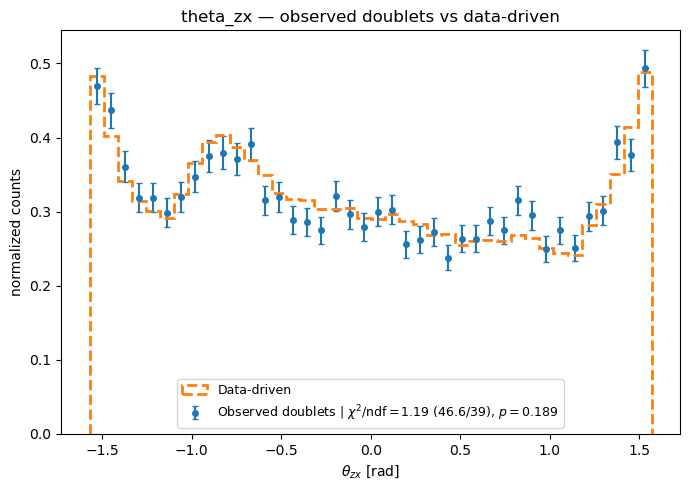

theta_zx — observed doublets vs data-driven
  normalization: shape
  scale: 0.050513
  $\chi^2/\mathrm{ndf}=1.19$ (46.6/39), $p=0.189$


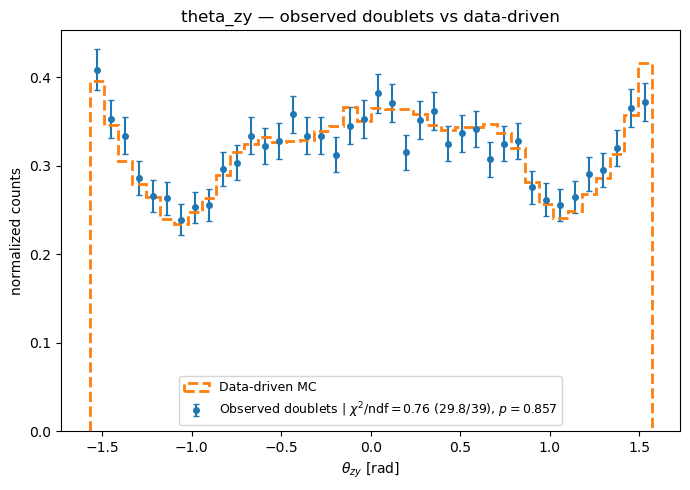

theta_zy — observed doublets vs data-driven
  normalization: shape
  scale: 0.050513
  $\chi^2/\mathrm{ndf}=0.76$ (29.8/39), $p=0.857$


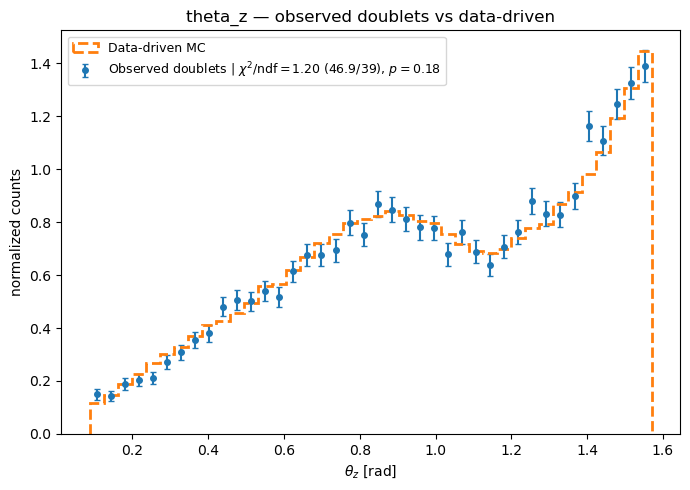

theta_z — observed doublets vs data-driven
  normalization: shape
  scale: 0.050513
  $\chi^2/\mathrm{ndf}=1.20$ (46.9/39), $p=0.18$


(46.918957098086935, 39, 0.17966444031668674)

In [24]:
overlay_hist_simple(
    obs_blind["theta_zx"], mc_blind["theta_zx"],
    "Observed doublets", "Data-driven",
    title="theta_zx — observed doublets vs data-driven",
    xlabel=r"$\theta_{zx}$ [rad]", bins=40,
)

overlay_hist_simple(
    obs_blind["theta_zy"], mc_blind["theta_zy"],
    "Observed doublets", "Data-driven MC",
    title="theta_zy — observed doublets vs data-driven",
    xlabel=r"$\theta_{zy}$ [rad]", bins=40,
)

overlay_hist_simple(
    obs_blind["theta_z"], mc_blind["theta_z"],
    "Observed doublets", "Data-driven MC",
    title="theta_z — observed doublets vs data-driven",
    xlabel=r"$\theta_{z}$ [rad]", bins=40,
)